Running randomised tests for the bounds...
Test completed. In 0 out of 100 cases, the alternative bound exceeded the conjectural minimum.


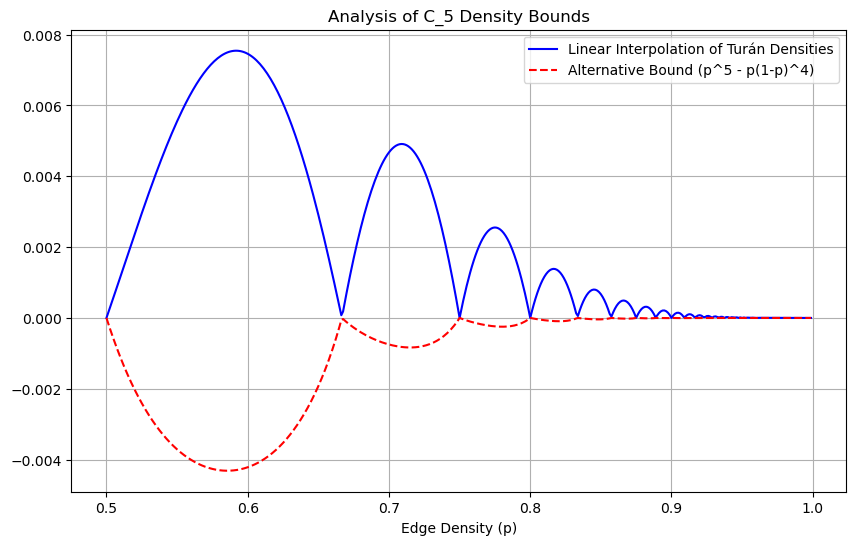

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def falling_factorial(n, k):
  if k <= 0:
    return 1.0
  result = 1.0
  for i in range(k):
    result *= (n - i)
  return result

def objective_f(x, p, k):
  y = 1.0 - (k - 1) * x
  if y <= 0.0:
    return np.inf
  
  term_p1 = falling_factorial(k - 1, 2) * (x**2)
  term_p2 = 2.0 * (k - 1) * x * y
  rho = (p - term_p1 - term_p2) / (y**2)
  
  # Allow a tiny float tolerance, then clip to strict bounds
  if rho < -1e-7 or rho > 0.5 + 1e-7:
    return np.inf
  rho = np.clip(rho, 0.0, 0.5)

  c1 = 0.1 * falling_factorial(k - 1, 5) + 0.5 * falling_factorial(k - 1, 4) + 0.5 * falling_factorial(k - 1, 3)
  t1 = c1 * (x**5)
  
  c2 = 0.5 * falling_factorial(k - 1, 4) + 1.5 * falling_factorial(k - 1, 3) + 0.5 * falling_factorial(k - 1, 2)
  t2 = c2 * (x**4) * y
  
  c3 = (0.5 + 0.5 * rho) * falling_factorial(k - 1, 3) + (1.0 + 0.5 * rho) * falling_factorial(k - 1, 2)
  t3 = c3 * (x**3) * (y**2)
  
  c4 = (0.5 * rho + 0.5 * rho**2) * falling_factorial(k - 1, 2) + 0.5 * rho * (k - 1)
  t4 = c4 * (x**2) * (y**3)
  
  t5 = 0.5 * (rho**3) * (k - 1) * x * (y**4)
  
  return t1 + t2 + t3 + t4 + t5

def get_f_min(p):
  if p <= 0.5:
    return 0.0
  
  k = 2
  while p > 1.0 - 1.0 / (k + 1) + 1e-9:
    k += 1
      
  # Calculate exact mathematical bounds for x to satisfy 0 <= rho <= 0.5
  val = 2.0 * (k - 1) * (k - p * (k + 1))
  val = max(0.0, val) # Prevent math domain errors from floating point precision
  
  s1 = (k - 1 - np.sqrt(val)) / (k**2 - 1)
  s2 = (k - 1 + np.sqrt(val)) / (k**2 - 1)
  
  res = minimize_scalar(
    objective_f,
    bounds=(s1, s2),
    args=(p, k),
    method='bounded'
  )
  
  # Multiply by 10 to convert from unlabelled copy density to homomorphism density
  return res.fun * 10.0

def test_bounds_inequality():
  print("Running randomised tests for the bounds...")
  test_ps = np.random.uniform(0.51, 0.99, 100)
  failures = 0
  
  for p in test_ps:
    f_val = get_f_min(p)
    alt_bound = p**5 - p * (1.0 - p)**4
    
    if alt_bound > f_val:
      failures += 1
      
  print(f"Test completed. In {failures} out of 100 cases, the alternative bound exceeded the conjectural minimum.")

def plot_bounds():
  p_vals = np.linspace(0.5, 1.0, 400, endpoint=False)
  f_min_vals = [get_f_min(p) for p in p_vals]
  baseline_vals = [max(0.0, p**5 - p * (1.0 - p)**4) for p in p_vals]

  turan_densities = [1 - 1 / k for k in range(2, 1001)]
  turan_c5_densities = [(1 - 1 / k)**5 - (1 - 1 / k) * (1 / k)**4 for k in range(2, 1001)]

  # interpolate the Turán densities for plotting
  turan_linear_vals = np.interp(p_vals, turan_densities, turan_c5_densities)

  plt.figure(figsize=(10, 6))
  plt.plot(p_vals, [turan_linear_val - f_min_val for turan_linear_val, f_min_val in zip(turan_linear_vals, f_min_vals)], 'b-', label='Linear Interpolation of Turán Densities')
  plt.plot(p_vals, [baseline_val - f_min_val for baseline_val, f_min_val in zip(baseline_vals, f_min_vals)], 'r--', label='Alternative Bound (p^5 - p(1-p)^4)')
  
  plt.title('Analysis of C_5 Density Bounds')
  plt.xlabel('Edge Density (p)')
  plt.legend()
  plt.grid(True)
  plt.show()

if __name__ == "__main__":
  test_bounds_inequality()
  plot_bounds()